# Handwritten Digit Recognition using CNN on MNIST Dataset

This notebook builds a Convolutional Neural Network (CNN) to classify handwritten digits (0-9) using the MNIST dataset.

## Dataset: MNIST (Modified National Institute of Standards and Technology)

The MNIST dataset is a benchmark dataset in machine learning for image classification.

### Details:
- **Total samples**: 70,000 grayscale images of handwritten digits
- **Training set**: 60,000 images
- **Test set**: 10,000 images
- **Image dimensions**: 28 × 28 pixels (784 pixels total)
- **Color channel**: 1 (grayscale)
- **Classes**: 10 digits (0 through 9)

### Goal:
Train a CNN to classify each 28×28 grayscale image into one of 10 digit classes (0-9).

## Model Architecture: CNN

1. **Conv2D Layer** — 32 filters, 5×5 kernel, ReLU activation (detects low-level features like edges)
2. **MaxPooling2D Layer** — 2×2 pool size (reduces spatial dimensions)
3. **Conv2D Layer** — 64 filters, 3×3 kernel, ReLU activation (detects higher-level features)
4. **MaxPooling2D Layer** — 2×2 pool size
5. **Flatten Layer** — Converts 2D feature maps into a 1D vector
6. **Dense Layer** — 128 neurons, ReLU activation (fully connected classification layer)
7. **Dense Layer** — 10 neurons, Softmax activation (outputs probability per digit 0-9)

## 1. Setup and Imports

In [17]:
# Import required libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, Sequential
import matplotlib.pyplot as plt

# Set random seed for reproducibility
tf.random.set_seed(42)

## 2. Load the MNIST Dataset

The dataset is loaded directly from TensorFlow's built-in datasets (no external download needed).

In [18]:
# Load MNIST dataset from TensorFlow's built-in datasets
# Returns: (train_images, train_labels), (test_images, test_labels)
((train_x, train_y), (test_x, test_y)) = datasets.mnist.load_data()

In [19]:
# Check the shape of the training data
# (60000, 28, 28) means 60,000 images, each 28x28 pixels
print(f"Training data shape: {train_x.shape}")
print(f"Training labels shape: {train_y.shape}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)


## 3. Data Preprocessing

Steps:
1. Reshape images to add the channel dimension (28×28×1)
2. Normalize pixel values from [0, 255] to [0.0, 1.0]
3. Convert labels to one-hot encoded vectors

In [20]:
# Reshape images to add the single color channel dimension
# Original shape: (60000, 28, 28) → New shape: (60000, 28, 28, 1)
# CNN layers expect input shape (height, width, channels)
train_x = train_x.reshape(60000, 28, 28, 1)
test_x = test_x.reshape(10000, 28, 28, 1)

In [21]:
# Verify the new shape after adding the channel dimension
print(f"Training data reshaped: {train_x.shape}")
print(f"Test data reshaped: {test_x.shape}")

Training data reshaped: (60000, 28, 28, 1)
Test data reshaped: (10000, 28, 28, 1)


In [22]:
# Normalize pixel values from integers [0, 255] to floats [0.0, 1.0]
# This helps the neural network converge faster and more stably
train_x = train_x.astype('float32') / 255.0
test_x = test_x.astype('float32') / 255.0

In [23]:
# Convert labels to one-hot encoded vectors
# Example: label 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This format is required for categorical crossentropy loss
train_y = tf.keras.utils.to_categorical(train_y, num_classes=10)
test_y = tf.keras.utils.to_categorical(test_y, num_classes=10)

In [24]:
# Verify one-hot encoding: first label should be 5 → [0,0,0,0,0,1,0,0,0,0]
print(f"First training label (one-hot): {train_y[0]}")

First training label (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 4. Visualize Sample Images

Let's look at some sample digits from the dataset to understand what we're working with.

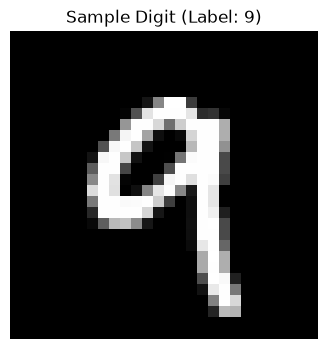

In [25]:
# Display a sample digit from the training set (index 110)
# The image is 28x28 pixels in grayscale
plt.figure(figsize=(4, 4))
plt.imshow(train_x[110].reshape(28, 28), cmap='gray')
plt.title(f"Sample Digit (Label: {tf.argmax(train_y[110]).numpy()})")
plt.axis('off')
plt.show()

## 5. Build the CNN Model

In [26]:
# Create a Sequential model for the CNN
model1 = Sequential()

# First Convolutional Block:
# Conv2D: 32 filters, 5x5 kernel, 'same' padding preserves spatial dimensions
# Input shape: 28x28x1 (height=28, width=28, channels=1)
# ReLU activation introduces non-linearity
model1.add(layers.Conv2D(filters=32,
                         kernel_size=5,
                         strides=1,
                         padding='same',
                         activation=tf.nn.relu,
                         input_shape=(28, 28, 1)))

# MaxPooling: 2x2 pool with stride 2 reduces feature map size by half
# This downsamples the image and reduces computational load
model1.add(layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

In [27]:
# Second Convolutional Block:
# Conv2D: 64 filters, 3x3 kernel — detects more complex features
model1.add(layers.Conv2D(filters=64,
                         kernel_size=3,
                         strides=(1, 1),
                         padding='same',
                         activation=tf.nn.relu))

# Another MaxPooling layer to further reduce spatial dimensions
model1.add(layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))

# Flatten: convert the 2D feature maps into a 1D vector for the dense layers
model1.add(layers.Flatten())

# Fully Connected Layer: 128 neurons with ReLU activation
# This layer learns high-level combinations of the detected features
model1.add(layers.Dense(units=128, activation=tf.nn.relu))

# Output Layer: 10 neurons with Softmax activation
# Each neuron outputs the probability of the input belonging to one of the 10 digits
# The digit with the highest probability is the model's prediction
model1.add(layers.Dense(units=10, activation=tf.nn.softmax))

In [28]:
# Display the complete model architecture
# Shows each layer, output shape, and number of trainable parameters
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,154 (1.61 MB)

 Trainable params: 422,154 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile and Train the Model

In [29]:
# Compile the model:
# - optimizer='adam': adaptive moment estimation, good default optimizer
# - loss='categorical_crossentropy': standard loss for multi-class classification
# - metrics=['accuracy']: track classification accuracy
model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

# Train the model:
# - epochs=10: pass through the entire training set 10 times
# - validation_split=0.20: hold out 20% of training data for validation
# - batch_size=128: update weights after every 128 samples
hist = model1.fit(x=train_x,
                  y=train_y,
                  epochs=10,
                  validation_split=0.20,
                  batch_size=128,
                  verbose=1)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9327 - loss: 0.2255 - val_accuracy: 0.9799 - val_loss: 0.0653
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9826 - loss: 0.0577 - val_accuracy: 0.9873 - val_loss: 0.0430
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9877 - loss: 0.0405 - val_accuracy: 0.9877 - val_loss: 0.0415
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9910 - loss: 0.0298 - val_accuracy: 0.9885 - val_loss: 0.0389
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.9893 - val_loss: 0.0417
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9948 - loss: 0.0169 - val_accuracy: 0.9894 - val_loss: 0.0414
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9953 - loss: 0.0145 - val_accuracy: 0.9860 - val_loss: 0.0576
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9969 - loss: 0.0112 - val_accu

## 7. Visualize Training Progress

Plot accuracy and loss curves to check for overfitting and convergence.

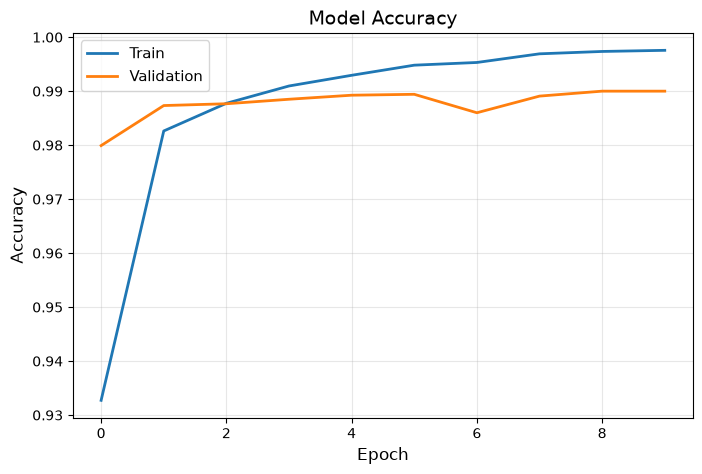

In [30]:
# Plot training and validation accuracy over epochs
# Accuracy should increase for both; a large gap suggests overfitting
plt.figure(figsize=(8, 5))
plt.plot(hist.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['Train', 'Validation'], loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

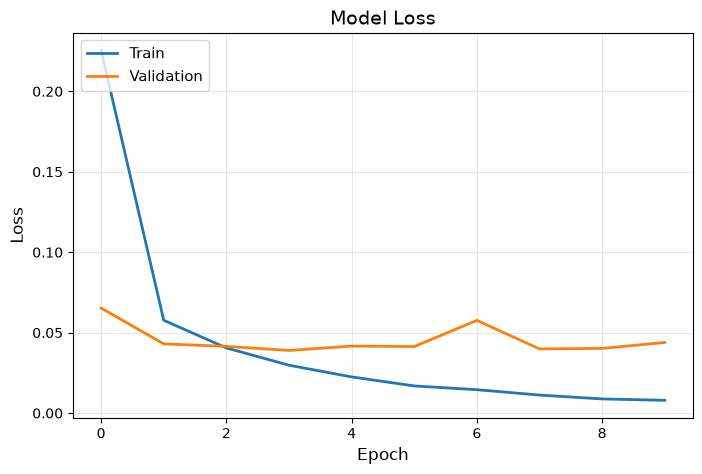

In [31]:
# Plot training and validation loss over epochs
# Both curves should decrease; divergence indicates overfitting
plt.figure(figsize=(8, 5))
plt.plot(hist.history['loss'], label='Train Loss', linewidth=2)
plt.plot(hist.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(['Train', 'Validation'], loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## 8. Save the Trained Model

The model is saved locally in the Week 3 directory for later use without retraining.

In [32]:
# Save the trained CNN model to the local Week 3 directory
# The .keras format preserves the full model (architecture + weights + optimizer state)
model1.save("mnist_cnn_model.keras")
print("Model saved to Week 3/mnist_cnn_model.keras")

Model saved to Week 3/mnist_cnn_model.keras


---

# Exercise: Fashion MNIST Classification using CNN

Now it's your turn! Apply the same CNN pipeline to a **different image classification dataset**: Fashion MNIST.

## Dataset: Fashion MNIST

Fashion MNIST is a drop-in replacement for the classic MNIST dataset, containing images of clothing items instead of handwritten digits.

### Details:
- **Total samples**: 70,000 grayscale images
- **Training set**: 60,000 images
- **Test set**: 10,000 images
- **Image dimensions**: 28 × 28 pixels (same as MNIST!)
- **Color channel**: 1 (grayscale)
- **Classes**: 10 clothing categories

### Class Labels:
| Label | Description |
|-------|-------------|
| 0     | T-shirt/top |
| 1     | Trouser     |
| 2     | Pullover    |
| 3     | Dress       |
| 4     | Coat        |
| 5     | Sandal      |
| 6     | Shirt       |
| 7     | Sneaker     |
| 8     | Bag         |
| 9     | Ankle boot  |

### Your Goal:
Complete the code below to:
1. Load the Fashion MNIST dataset (built into TensorFlow — no external file needed!)
2. Preprocess the data (reshape, normalize, one-hot encode)
3. Build, compile, train, and evaluate a CNN model
4. Hint: The preprocessing and CNN architecture can be almost identical to what we did for MNIST!

In [ ]:
# ===== YOUR TURN! Complete the TODOs below =====

# TODO 1: Import necessary libraries
# Hint: You'll need tensorflow, datasets/layers/Sequential from tensorflow.keras,
# and matplotlib.pyplot
import tensorflow as tf
from tensorflow.keras import datasets, layers, Sequential
import matplotlib.pyplot as plt


# TODO 2: Load the Fashion MNIST dataset
# Use datasets.fashion_mnist.load_data() — it works just like datasets.mnist.load_data()
# Returns: ((train_x, train_y), (test_x, test_y))
((train_x, train_y), (test_x, test_y)) = ...  # ← Fill this in


# TODO 3: Print the shape of the training data
# Use .shape on train_x and train_y
print("Training data shape:", ...)   # train_x.shape
print("Training labels shape:", ...)  # train_y.shape


# TODO 4: Reshape images to add the channel dimension (28, 28) → (28, 28, 1)
# Use .reshape(60000, 28, 28, 1) for train_x and .reshape(10000, 28, 28, 1) for test_x
train_x = ...  # ← Reshape train_x
test_x = ...   # ← Reshape test_x


# TODO 5: Normalize pixel values from [0, 255] to [0.0, 1.0]
# Convert to float32 and divide by 255.0
train_x = ...  # ← Fill this in
test_x = ...   # ← Fill this in


# TODO 6: Convert labels to one-hot encoded vectors
# Use tf.keras.utils.to_categorical(..., num_classes=10)
train_y = ...  # ← Fill this in
test_y = ...   # ← Fill this in


# TODO 7: Build a Sequential CNN model
# Use the same architecture as the MNIST model (model1) above
# - Conv2D(32, 5, padding='same', activation='relu', input_shape=(28,28,1))
# - MaxPool2D(2,2)
# - Conv2D(64, 3, padding='same', activation='relu')
# - MaxPool2D(2,2)
# - Flatten()
# - Dense(128, activation='relu')
# - Dense(10, activation='softmax')
model = ...  # ← Create Sequential()
# model.add(...)  # First Conv2D + MaxPool
# model.add(...)  # Second Conv2D + MaxPool
# model.add(...)  # Flatten
# model.add(...)  # Dense 128
# model.add(...)  # Output Dense 10


# TODO 8: Display the model summary
# model.summary()


# TODO 9: Compile the model
# Use optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']
# model.compile(...)


# TODO 10: Train the model for 10 epochs with batch_size=128
# Use validation_split=0.20 and verbose=1
# hist = model.fit(...)


# TODO 11: Plot the training and validation accuracy over epochs
# Copy the plotting code from the MNIST notebook (cell 14)


# TODO 12: Evaluate the model on the test set and print the test accuracy
# model_loss, model_accuracy = model.evaluate(test_x, test_y, verbose=0)
# print(f"Test Accuracy: {model_accuracy:.4f}")